* **Disciplina:** SIN5032 - Experimentação em Aprendizado de Máquina Supervisionado (EP02)
* **Professor:** Dr. Norton T. Roman
* **Discentes:**
  * Gláucio Soares da Silva (Nº USP 15031246)
  * Redy Rivas Idme (Nº USP 11962345)



1 - Instalação e Importação de Dependências

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

sns.set(style="whitegrid")
RANDOM_STATE = 42


2 - Carregamento da Base de Dados

In [2]:
df = pd.read_csv(
    "base_municipios.csv",
    sep=";",
    encoding="utf-8"
)

df.head()


,cd_ibge,nm_municipio,nm_microrrregiao,nm_mesorregiao,nm_estado,nm_regiao,populacao,empresas_ativas,densidade_demografica,numero_domicilios,pib_total,idh,renda_media,pea_dia,agencias_bancarias,agencias_cooperativas,investimentos_bancarios,credito_bancario,cooperados_pf,cooperados_pj
0,310010,Abadia dos Dourados,Patrocínio,Triângulo Mineiro/Alto Paranaíba,MG,Sudeste,6.365,627,"7,22425","2.646,12","190.396,52","0,689","4.349,32","3.660,14",0,1,-,-,3.730,354.000
1,310020,Abaeté,Três Marias,Central Mineira,MG,Sudeste,23.161,3.301,"12,74634","9.335,49","641.970,99","0,698","4.581,38","13.389,29",2,3,226.908.357,364.185.908,5.743,1.086
2,310030,Abre Campo,Manhuaçu,Zona da Mata,MG,Sudeste,14.312,1.248,"30,41547","5.115,85","331.512,39","0,654","3.872,14","7.212,74",1,1,81.794.251,112.913.104,2.699,481.000
3,310040,Acaiaca,Ponte Nova,Zona da Mata,MG,Sudeste,3.997,335,"39,22858","1.559,30","85.065,90","0,63","2.810,52","1.692,68",0,0,-,-,199.000,60.000
4,310050,Açucena,Ipatinga,Vale do Rio Doce,MG,Sudeste,8.995,531,"11,03113","3.389,21","172.093,76","0,61","3.095,43","2.947,59",0,1,-,-,1.199,112.000


3 - Seleção das Variáveis Críticas

In [3]:
df = df[[
    # Estrutura socioeconômica
    "densidade_demografica",
    "numero_domicilios",
    "pib_total",
    "renda_media",
    "idh",
    "pea_dia",

    # Sistema financeiro
    "agencias_bancarias",
    "agencias_cooperativas",
    "credito_bancario",
    "investimentos_bancarios",

    # Base cooperativa
    "cooperados_pf",
    "cooperados_pj",

    # Universos
    "populacao",
    "empresas_ativas",

    # Região
    "nm_regiao"
]].copy()


4 - Limpeza dos Dados, Engenharia de Features Estabilizada

In [ ]:
def to_float_br(df, cols):
    return (
        df[cols]
        .astype(str)
        .replace({"-": np.nan, "": np.nan})
        .apply(lambda s: s.str.replace(".", "", regex=False)
                          .str.replace(",", ".", regex=False))
        .apply(pd.to_numeric, errors="coerce")
    )

# Limpeza inicial de strings numéricas brasileiras
cols_numeric = df.columns.drop("nm_regiao")
df[cols_numeric] = to_float_br(df, cols_numeric)

# Tratamento prévio de nulos nas agências para evitar perda de dados e divisões por zero
df["agencias_bancarias"] = df["agencias_bancarias"].fillna(0)
df["agencias_cooperativas"] = df["agencias_cooperativas"].fillna(0)

# Construção do Público-Alvo (PI) Total por município
df["pop_empresa"] = df["populacao"] + df["empresas_ativas"]

# Market Share Ponderado Real (Total de Cooperados / Público-Alvo Total)
# Dividir por dois (como estava antes) supervalorizava municípios pequenos onde PJ era volátil.
df["mks_total"] = (df["cooperados_pf"] + df["cooperados_pj"]) / df["pop_empresa"].replace(0, np.nan)

# Densidades e razões ajustadas para municípios sem agências físicas
df["dens_bancaria"] = np.where(df["agencias_bancarias"] > 0, df["pop_empresa"] / df["agencias_bancarias"], df["pop_empresa"])
df["dens_cooperativa"] = np.where(df["agencias_cooperativas"] > 0, df["pop_empresa"] / df["agencias_cooperativas"], df["pop_empresa"])
df["razao_coop_bancos"] = df["agencias_cooperativas"] / (df["agencias_bancarias"] + 1)

# Indicadores financeiros per capita do público-alvo
df["credito_per_pop_empresa"] = df["credito_bancario"] / df["pop_empresa"].replace(0, np.nan)
df["investimento_per_pop_empresa"] = df["investimentos_bancarios"] / df["pop_empresa"].replace(0, np.nan)

# Aplicação do LOG1P em TODAS as variáveis numéricas incluindo o alv, isso remove a assimetria destrutiva que gera os R² negativos e reequilibra o peso das pequenas cidades
cols_log = ["densidade_demografica", "renda_media", "credito_per_pop_empresa", "investimento_per_pop_empresa", "mks_total"]
for col in cols_log:
    df[col] = np.log1p(df[col])

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove registros nulos na variável dependente e reseta o índice global da base de forma absoluta
df = df.dropna(subset=["mks_total"]).reset_index(drop=True)


5 - Separação Geográfica Inicial

In [5]:
df_sul = df[df["nm_regiao"] == "Sul"].copy().reset_index(drop=True)
df_sudeste = df[df["nm_regiao"] == "Sudeste"].copy().reset_index(drop=True)


6 - Análise Exploratória da Base Completa


===== EDA BASE COMPLETA - SUL =====


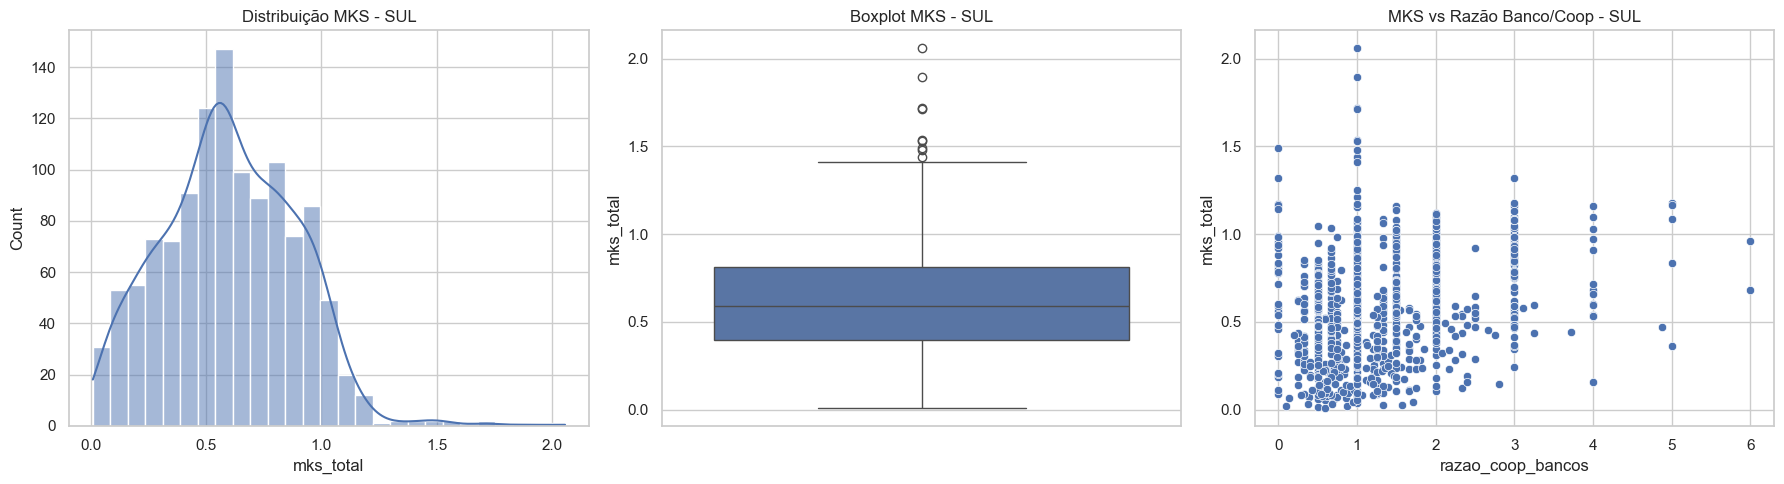


===== EDA BASE COMPLETA - SUDESTE =====


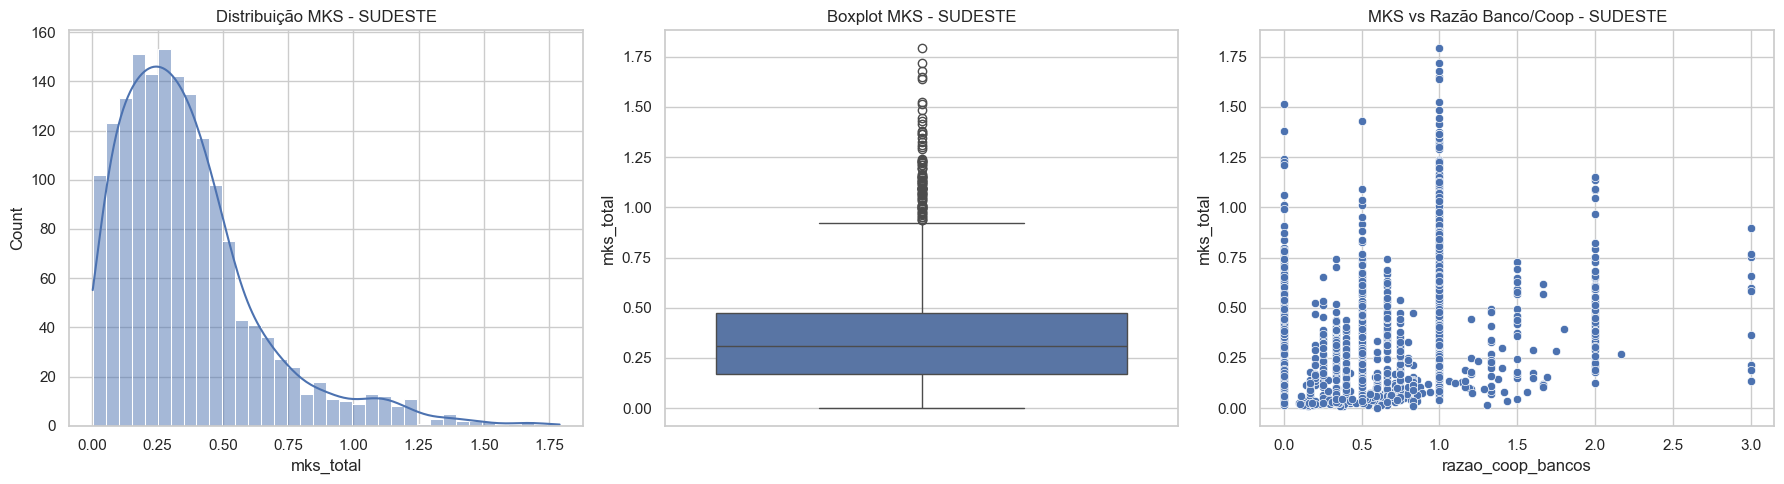

In [6]:
def eda_base_completa(df_regiao, nome):
    print(f"\n===== EDA BASE COMPLETA - {nome} =====")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df_regiao["mks_total"], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribuição MKS - {nome}")

    sns.boxplot(y=df_regiao["mks_total"], ax=axes[1])
    axes[1].set_title(f"Boxplot MKS - {nome}")

    sns.scatterplot(data=df_regiao, x="razao_coop_bancos", y="mks_total", ax=axes[2])
    axes[2].set_title(f"MKS vs Razão Banco/Coop - {nome}")

    plt.tight_layout()
    plt.show()

eda_base_completa(df_sul, "SUL")
eda_base_completa(df_sudeste, "SUDESTE")


7 - Amostragem de 10%

In [7]:
df_sul_modelo, df_sul_eda = train_test_split(
    df_sul, test_size=0.10, random_state=RANDOM_STATE
)
df_sul_modelo = df_sul_modelo.reset_index(drop=True)
df_sul_eda = df_sul_eda.reset_index(drop=True)

df_sudeste_modelo, df_sudeste_eda = train_test_split(
    df_sudeste, test_size=0.10, random_state=RANDOM_STATE
)
df_sudeste_modelo = df_sudeste_modelo.reset_index(drop=True)
df_sudeste_eda = df_sudeste_eda.reset_index(drop=True)

print(f"Sul - Base de Treinamento: {df_sul_modelo.shape[0]} municípios | Base EDA: {df_sul_eda.shape[0]}")
print(f"Sudeste - Base de Treinamento: {df_sudeste_modelo.shape[0]} municípios | Base EDA: {df_sudeste_eda.shape[0]}")


Sul - Base de Treinamento: 1071 municípios | Base EDA: 120
Sudeste - Base de Treinamento: 1501 municípios | Base EDA: 167


8 - Análise Exploratória dos Dados de Amostra


===== EDA AMOSTRA - SUL =====


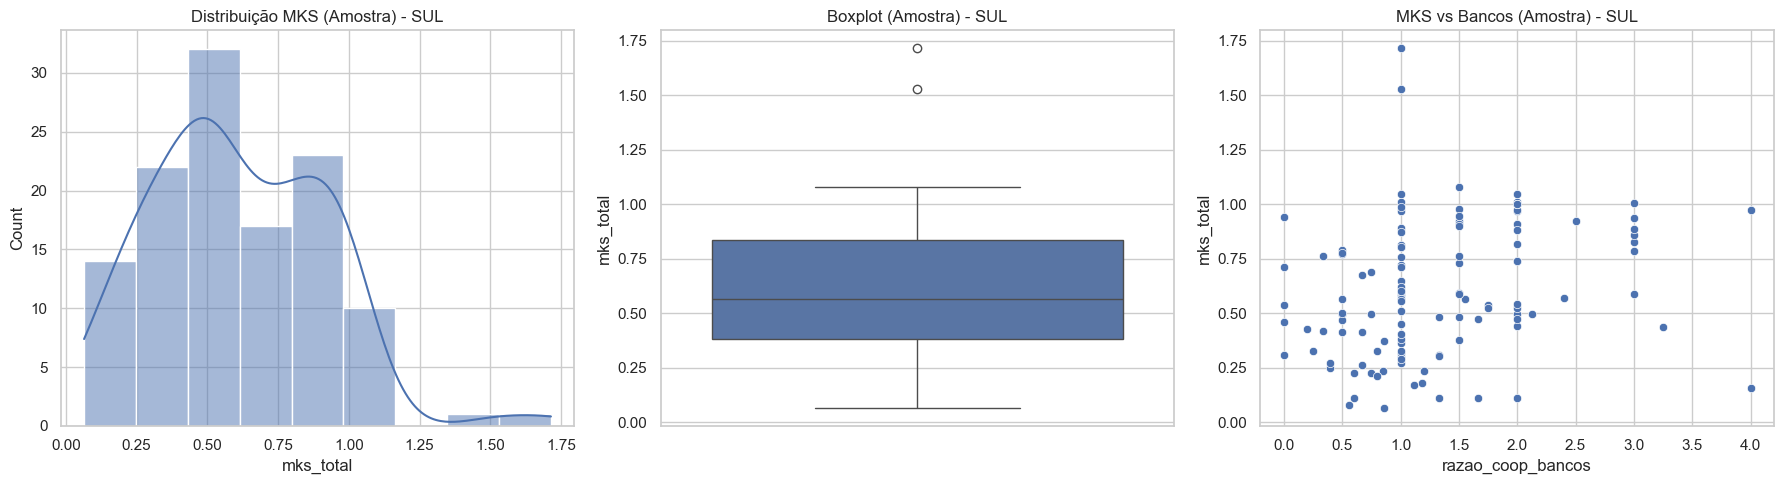


===== EDA AMOSTRA - SUDESTE =====


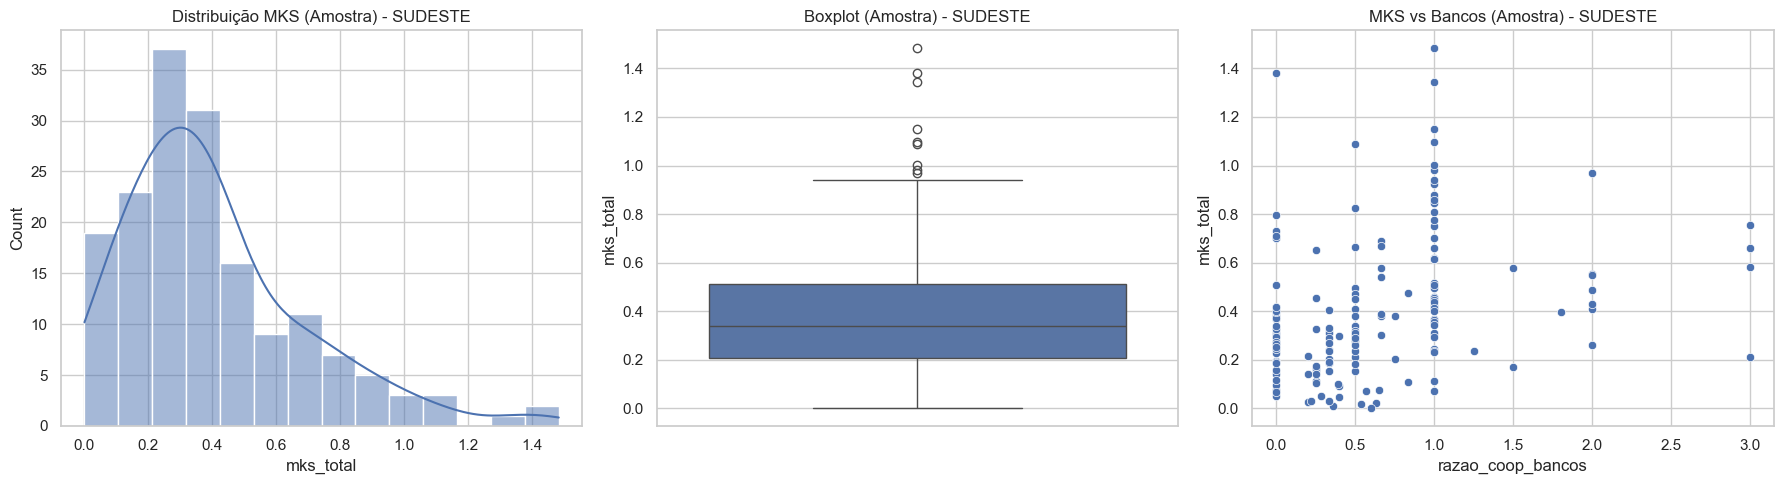

In [8]:
def eda_amostra(df_regiao, nome):
    print(f"\n===== EDA AMOSTRA - {nome} =====")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df_regiao["mks_total"], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribuição MKS (Amostra) - {nome}")

    sns.boxplot(y=df_regiao["mks_total"], ax=axes[1])
    axes[1].set_title(f"Boxplot (Amostra) - {nome}")

    sns.scatterplot(data=df_regiao, x="razao_coop_bancos", y="mks_total", ax=axes[2])
    axes[2].set_title(f"MKS vs Bancos (Amostra) - {nome}")

    plt.tight_layout()
    plt.show()

eda_amostra(df_sul_eda, "SUL")
eda_amostra(df_sudeste_eda, "SUDESTE")


9 - Definição de Variáveis Independentes Limpas

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Lista de todas as features potenciais que o seu PDF planejava testar
features_vif_teste = [
    "densidade_demografica", "numero_domicilios", "pib_total",
    "renda_media", "idh", "pea_dia",
    "dens_bancaria", "dens_cooperativa",
    "razao_coop_bancos",
    "credito_per_pop_empresa",
    "investimento_per_pop_empresa"
]

def executar_diagnostico_vif(df_sul_mod, df_sudeste_mod, features, threshold=10.0):
    """Une as bases de modelagem e remove iterativamente variáveis com VIF > threshold"""
    # Une os 90% dos dados destinados à modelagem para um cálculo unificado e justo
    df_combinado = pd.concat([df_sul_mod, df_sudeste_mod], axis=0)
    
    # Garante a remoção de NaNs estritamente para o cálculo do VIF (protege o statsmodels)
    X = df_combinado[features].dropna()
    
    print("--- 1. Cálculo Inicial do VIF (Com todas as variáveis do PDF) ---")
    X_scaled_init = StandardScaler().fit_transform(X)
    vif_init = pd.DataFrame({
        "Variável": X.columns,
        "VIF Inicial": [variance_inflation_factor(X_scaled_init, i) for i in range(X.shape[1])]
    }).sort_values("VIF Inicial", ascending=False)
    print(vif_init.round(2))
    print("-" * 60)
    
    # Algoritmo de eliminação iterativa backward (Critério Rígido de VIF < 10)
    while True:
        X_scaled = StandardScaler().fit_transform(X)
        vif_values = [variance_inflation_factor(X_scaled, i) for i in range(X.shape[1])]
        max_vif = max(vif_values)
        
        if max_vif > threshold:
            max_idx = vif_values.index(max_vif)
            var_removida = X.columns[max_idx]
            print(f"Eliminando a variável colinear: {var_removida} (VIF: {round(max_vif, 2)})")
            X = X.drop(columns=[var_removida])
        else:
            break
            
    print("-" * 60)
    print("--- 2. Tabela Final do VIF (Apenas variáveis aprovadas < 10) ---")
    vif_final = pd.DataFrame({
        "Variável": X.columns,
        "VIF Final": [variance_inflation_factor(StandardScaler().fit_transform(X), i) for i in range(X.shape[1])]
    }).sort_values("VIF Final", ascending=False)
    print(vif_final.round(2))
    
    return X.columns.tolist()

# Executa o algoritmo iterativo e salva a lista segura na variável 'features_finais'
features_finais = executar_diagnostico_vif(df_sul_modelo, df_sudeste_modelo, features_vif_teste, threshold=10.0)



--- 1. Cálculo Inicial do VIF (Com todas as variáveis do PDF) ---
                        Variável  VIF Inicial
5                        pea_dia       243.19
1              numero_domicilios       190.74
2                      pib_total        28.38
4                            idh         3.65
3                    renda_media         3.36
0          densidade_demografica         2.86
6                  dens_bancaria         2.48
7               dens_cooperativa         2.32
10  investimento_per_pop_empresa         1.77
9        credito_per_pop_empresa         1.60
8              razao_coop_bancos         1.49
------------------------------------------------------------
Eliminando a variável colinear: pea_dia (VIF: 243.19)
Eliminando a variável colinear: numero_domicilios (VIF: 21.44)
------------------------------------------------------------
--- 2. Tabela Final do VIF (Apenas variáveis aprovadas < 10) ---
                       Variável  VIF Final
3                           idh    

10 - Regressão Linear Múltipla Segmentada por Porte Regional

In [10]:
import statsmodels.api as sm

def treinar_regressao_por_porte(df_modelo, features, nome_regiao):
    # Alinhamento rígido de índices e remoção de nulos
    df_final = df_modelo[features + ["mks_total", "pop_empresa"]].dropna().reset_index(drop=True)

    # REMOÇÃO DE OUTLIERS: Filtra os 2% maiores municípios
    limite_outlier = df_final["pop_empresa"].quantile(0.98)
    df_final = df_final[df_final["pop_empresa"] <= limite_outlier].reset_index(drop=True)

    # REGRAS DE CORTE REGIONAIS: Tercis calculados de forma isolada para cada região
    q33 = df_final["pop_empresa"].quantile(0.33)
    q66 = df_final["pop_empresa"].quantile(0.66)

    tabelas_portes = []

    # Loop pelos segmentos de porte
    for porte, filtro in [
        ("PEQUENO", df_final["pop_empresa"] <= q33),
        ("MEDIO", (df_final["pop_empresa"] > q33) & (df_final["pop_empresa"] <= q66)),
        ("GRANDE", df_final["pop_empresa"] > q66)
    ]:
        df_porte = df_final[filtro].reset_index(drop=True)
        
        if len(df_porte) < 30:
            continue

        X = df_porte[features]
        y = df_porte["mks_total"]

        # Divisão padrão de treino/teste dentro do segmento (70/30)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.30, random_state=RANDOM_STATE
        )

        # Padronização estatística
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

        # O statsmodels exige intercepto explícito (adiciona coluna de constantes)
        X_train_ols = sm.add_constant(X_train_scaled_df)
        X_test_ols = sm.add_constant(X_test_scaled_df)

        # Ajuste do Modelo OLS
        ols_model = sm.OLS(y_train.reset_index(drop=True), X_train_ols).fit()
        
        # Predição e métricas
        y_pred = ols_model.predict(X_test_ols)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        # Coleta de coeficientes e p-valores
        coefs = ols_model.params.drop("const")
        p_values = ols_model.pvalues.drop("const")

        # Construção da tabela de saída usando dicionários (evita problemas de merge de texto)
        linhas = []
        linhas.append({"variavel": "R2", f"{nome_regiao}_{porte}": r2})
        linhas.append({"variavel": "MSE", f"{nome_regiao}_{porte}": mse})
        
        for var in features:
            # Mantém os nomes estritamente idênticos nas chaves e separa os valores em linhas consecutivas
            linhas.append({"variavel": f"{var} [coef]", f"{nome_regiao}_{porte}": coefs[var]})
            linhas.append({"variavel": f"{var} [p-valor]", f"{nome_regiao}_{porte}": p_values[var]})

        tabela_porte_consolidada = pd.DataFrame(linhas)
        tabelas_portes.append(tabela_porte_consolidada)

    # Une as três tabelas de portes da região atual
    tabela_regiao = tabelas_portes[0]
    for tab in tabelas_portes[1:]:
        tabela_regiao = pd.merge(tabela_regiao, tab, on="variavel", how="outer")
        
    return tabela_regiao

# Executa para as duas regiões
tabela_sul_segmentada = treinar_regressao_por_porte(df_sul_modelo, features_finais, "SUL")
tabela_sudeste_segmentada = treinar_regressao_por_porte(df_sudeste_modelo, features_finais, "SUDESTE")


11 - Consolidação e Visualização do Painel Estratégico Final

In [11]:
tabela_final = pd.merge(
    tabela_sul_segmentada,
    tabela_sudeste_segmentada,
    on="variavel",
    how="outer"
)

# Organiza a tabela para garantir que R2 e MSE fiquem sempre no topo
tabela_final = tabela_final.set_index("variavel")
metricas_topo = ["R2", "MSE"]
ordem_final = metricas_topo + [ind for ind in tabela_final.index if ind not in metricas_topo]

tabela_final = tabela_final.loc[ordem_final].reset_index()

# Formatação limpa de casas decimais
tabela_final = tabela_final.round(5)
tabela_final


,variavel,SUL_PEQUENO,SUL_MEDIO,SUL_GRANDE,SUDESTE_PEQUENO,SUDESTE_MEDIO,SUDESTE_GRANDE
0,R2,0.50105,0.11437,0.35598,0.13452,0.23313,0.41026
1,MSE,0.02381,0.02433,0.01214,0.02889,0.01070,0.00294
2,credito_per_pop_empresa [coef],0.00422,0.00294,-0.00506,-0.01256,-0.01691,0.00345
3,credito_per_pop_empresa [p-valor],0.82387,0.85290,0.70159,0.39209,0.08028,0.60174
4,dens_bancaria [coef],-0.02350,-0.01589,-0.07067,-0.10322,-0.03435,-0.03219
5,dens_bancaria [p-valor],0.35034,0.40914,0.00001,0.00000,0.01096,0.00003
6,dens_cooperativa [coef],-0.09105,-0.05711,-0.01041,0.00860,-0.01472,0.00323
7,dens_cooperativa [p-valor],0.00174,0.00364,0.41719,0.68141,0.30233,0.57334
8,densidade_demografica [coef],0.02447,-0.03476,-0.00713,0.00453,-0.00700,-0.01413
9,densidade_demografica [p-valor],0.12513,0.04553,0.60520,0.75017,0.41444,0.01446


In [12]:
pd.set_option('display.max_colwidth', None)

def gerar_matriz_diagnostico_metrica(df_painel):
    # Filtra as linhas contendo os coeficientes [coef]
    df_coefs = df_painel[df_painel["variavel"].str.contains(r"\[coef\]", regex=True)].copy()
    colunas_portes = [c for c in df_painel.columns if c != "variavel"]
    
    # Dicionário com a descrição puramente matemática/técnica de cada métrica
    descricoes_metricas = {
        "densidade_demografica": "Número de habitantes por quilômetro quadrado (hab/km²) no município.",
        "renda_media": "Valor médio dos rendimentos mensais declarados pela população local.",
        "idh": "Índice de Desenvolvimento Humano Municipal (escala de 0 a 1).",
        "dens_bancaria": "Volume do público-alvo total (população + empresas) dividido pelo número de agências bancárias tradicionais.",
        "dens_cooperativa": "Volume do público-alvo total (população + empresas) dividido pelo número de agências cooperativas.",
        "razao_coop_bancos": "Proporção direta entre o número de agências cooperativas e o número de agências bancárias concorrentes.",
        "credito_per_pop_empresa": "Volume total de crédito bancário concedido no município dividido pelo público-alvo total.",
        "investimento_per_pop_empresa": "Volume total de depósitos e investimentos bancários captados no município dividido pelo público-alvo total."
    }
    
    matriz_diagnostico = []
    
    for _, row in df_coefs.iterrows():
        var_base = row["variavel"].replace(" [coef]", "")
        
        # Resgata a linha de p-valor correspondente usando filtragem por string exata
        df_p_atual = df_painel[df_painel["variavel"] == f"{var_base} [p-valor]"]
        
        # Se por acaso não achar o p-valor da variável, pula para evitar quebras
        if df_p_atual.empty:
            continue
            
        linha_p_valor = df_p_atual.iloc[0]
        
        # Estrutura a linha com a Descrição da Métrica na frente
        dict_linha = {
            "Descrição da Métrica": descricoes_metricas.get(var_base, "Indicador numérico municipal."),
            "Variável Analisada": var_base
        }
        
        # Preenche o diagnóstico para as 6 colunas regionais/portes
        for col in colunas_portes:
            coef = row[col]
            p_val = linha_p_valor[col]
            
            if p_val < 0.05:
                direcao = "Positivo 🟢" if coef > 0 else "Negativo 🔴"
                dict_linha[col] = f"FAZ DIFERENÇA ({direcao})"
            else:
                dict_linha[col] = "Não Faz Diferença ⚪"
                
        matriz_diagnostico.append(dict_linha)
        
    df_resultado = pd.DataFrame(matriz_diagnostico)
    
    # Define a ordem final: Descrição primeiro, depois a Variável, depois as regiões
    colunas_ordenadas = ["Descrição da Métrica", "Variável Analisada"] + colunas_portes
    return df_resultado[colunas_ordenadas]

# Executa e exibe a tabela com a nova nomenclatura e largura total liberada
matriz_decisao_finais = gerar_matriz_diagnostico_metrica(tabela_final)
matriz_decisao_finais


,Descrição da Métrica,Variável Analisada,SUL_PEQUENO,SUL_MEDIO,SUL_GRANDE,SUDESTE_PEQUENO,SUDESTE_MEDIO,SUDESTE_GRANDE
0,Volume total de crédito bancário concedido no município dividido pelo público-alvo total.,credito_per_pop_empresa,Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪
1,Volume do público-alvo total (população + empresas) dividido pelo número de agências bancárias tradicionais.,dens_bancaria,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴),FAZ DIFERENÇA (Negativo 🔴),FAZ DIFERENÇA (Negativo 🔴),FAZ DIFERENÇA (Negativo 🔴)
2,Volume do público-alvo total (população + empresas) dividido pelo número de agências cooperativas.,dens_cooperativa,FAZ DIFERENÇA (Negativo 🔴),FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪
3,Número de habitantes por quilômetro quadrado (hab/km²) no município.,densidade_demografica,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴)
4,Índice de Desenvolvimento Humano Municipal (escala de 0 a 1).,idh,FAZ DIFERENÇA (Positivo 🟢),Não Faz Diferença ⚪,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪
5,Volume total de depósitos e investimentos bancários captados no município dividido pelo público-alvo total.,investimento_per_pop_empresa,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴)
6,Indicador numérico municipal.,pib_total,FAZ DIFERENÇA (Negativo 🔴),FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Negativo 🔴),Não Faz Diferença ⚪
7,Proporção direta entre o número de agências cooperativas e o número de agências bancárias concorrentes.,razao_coop_bancos,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Positivo 🟢),FAZ DIFERENÇA (Positivo 🟢),FAZ DIFERENÇA (Positivo 🟢),FAZ DIFERENÇA (Positivo 🟢)
8,Valor médio dos rendimentos mensais declarados pela população local.,renda_media,Não Faz Diferença ⚪,Não Faz Diferença ⚪,FAZ DIFERENÇA (Positivo 🟢),Não Faz Diferença ⚪,FAZ DIFERENÇA (Positivo 🟢),Não Faz Diferença ⚪
